<a href="https://colab.research.google.com/github/fideliseshun/DSRP-Research-Project/blob/main/DSRP_Research_Project_Messi_vs_Ronaldo_FIFA_World_Cup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Research Project - Messi vs Ronaldo FIFA World Cup**

**1. Importing Libraries, functions, and dataset**


In [ ]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score

In [ ]:
# Import dataset
url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/main/Ronaldo%20V.s.%20Messi/cleaned_goat_world_cup_data_level1.csv"
WorldCup_df = pd.read_csv(url)

**2. Cleaning and Wrangling Data**

In [ ]:
# Replacing 0 and 1 with no or yes in the following columns: starter, substitute, and is_knockout
WorldCup_df["starter"] = WorldCup_df["starter"].replace({0: "No", 1: "Yes"})
WorldCup_df["substitute"] = WorldCup_df["substitute"].replace({0: "No", 1: "Yes"})
WorldCup_df["is_knockout"] = WorldCup_df["is_knockout"].replace({0: "No", 1: "Yes"})
display(WorldCup_df.head())
WorldCup_df.info()
# Grouping data for Messi and Ronaldo
grouped = WorldCup_df.groupby("family_name")
messi_data = grouped.get_group("Messi")
ronaldo_data = grouped.get_group("Ronaldo")
#print(messi_data["minutes_played"].sum())
#print(ronaldo_data["minutes_played"].sum())

,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,team_name,player_id,given_name,...,starter,substitute,minutes_played,total_goals,open_play_goals,penalty_goals,assists,is_knockout,yellow_cards,red_cards
0,WC-2006,2006 FIFA Men's World Cup,M-2006-21,Argentina vs Serbia and Montenegro,2006-06-16,group stage,Group C,Argentina,P-14758,Lionel,...,No,Yes,30,1,1,0,0,No,0,0
1,WC-2006,2006 FIFA Men's World Cup,M-2006-40,Netherlands vs Argentina,2006-06-21,group stage,Group C,Argentina,P-14758,Lionel,...,Yes,No,90,0,0,0,0,No,0,0
2,WC-2006,2006 FIFA Men's World Cup,M-2006-50,Argentina vs Mexico,2006-06-24,round of 16,not applicable,Argentina,P-14758,Lionel,...,No,Yes,30,0,0,0,0,Yes,0,0
3,WC-2010,2010 FIFA Men's World Cup,M-2010-04,Argentina vs Nigeria,2010-06-12,group stage,Group B,Argentina,P-14758,Lionel,...,Yes,No,90,0,0,0,0,No,0,0
4,WC-2010,2010 FIFA Men's World Cup,M-2010-18,Argentina vs South Korea,2010-06-17,group stage,Group B,Argentina,P-14758,Lionel,...,Yes,No,90,0,0,0,0,No,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   tournament_id    48 non-null     object
 1   tournament_name  48 non-null     object
 2   match_id         48 non-null     object
 3   match_name       48 non-null     object
 4   match_date       48 non-null     object
 5   stage_name       48 non-null     object
 6   group_name       48 non-null     object
 7   team_name        48 non-null     object
 8   player_id        48 non-null     object
 9   given_name       48 non-null     object
 10  family_name      48 non-null     object
 11  starter          48 non-null     object
 12  substitute       48 non-null     object
 13  minutes_played   48 non-null     int64 
 14  total_goals      48 non-null     int64 
 15  open_play_goals  48 non-null     int64 
 16  penalty_goals    48 non-null     int64 
 17  assists          48 non-null     int6

**3. Creating Visulizations and Comparing Variables**

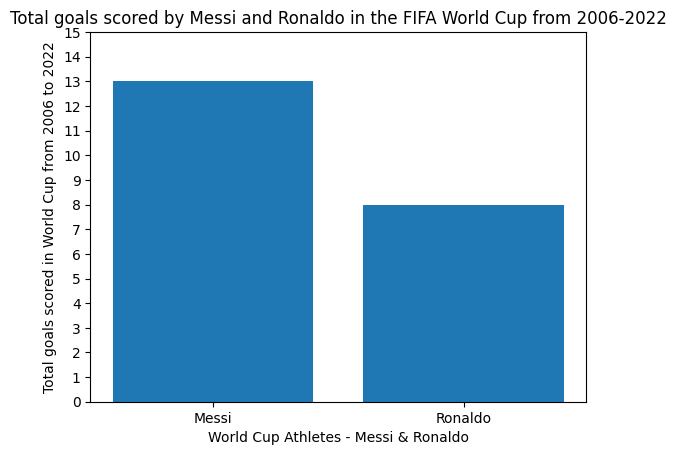

In [ ]:
import matplotlib.pyplot as plt
# Bar plot: Comparing total goals scored by Messi and Ronaldo in the World Cup from 2006 to 2022
athletes = WorldCup_df["family_name"].value_counts().nlargest(2).index
filtered_data = WorldCup_df[WorldCup_df["family_name"].isin(athletes)]
bars = filtered_data.groupby("family_name")["total_goals"].sum()
plt.bar(bars.index, bars)
plt.xlabel("World Cup Athletes - Messi & Ronaldo")
plt.ylabel("Total goals scored in World Cup from 2006 to 2022")
plt.title("Total goals scored by Messi and Ronaldo in the FIFA World Cup from 2006-2022")
plt.yticks(np.arange(0, 16, 1))
plt.show()

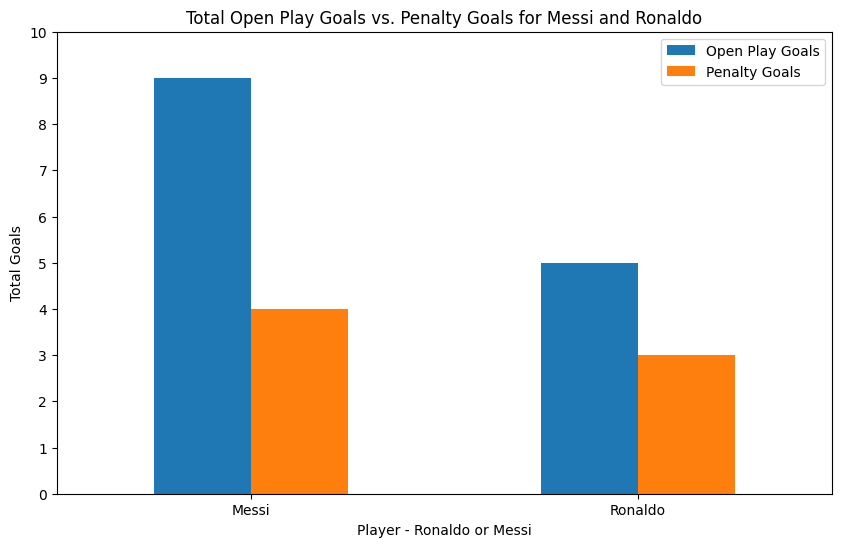

In [ ]:
# Bar plot: Comparing total Open play goals and penalty goals for Messi and Ronaldo

athletes = WorldCup_df["family_name"].value_counts().nlargest(2).index
filtered_data = WorldCup_df[WorldCup_df["family_name"].isin(athletes)]
goaltypes_df = filtered_data.groupby("family_name")[["open_play_goals", "penalty_goals"]].sum()

goaltypes_df.plot(kind="bar", figsize=(10, 6))
plt.title("Total Open Play Goals vs. Penalty Goals for Messi and Ronaldo")
plt.xlabel("Player - Ronaldo or Messi")
plt.ylabel("Total Goals")
plt.xticks(rotation=0)
plt.yticks(np.arange(0, 11, 1))
plt.legend(["Open Play Goals", "Penalty Goals"])
plt.show()

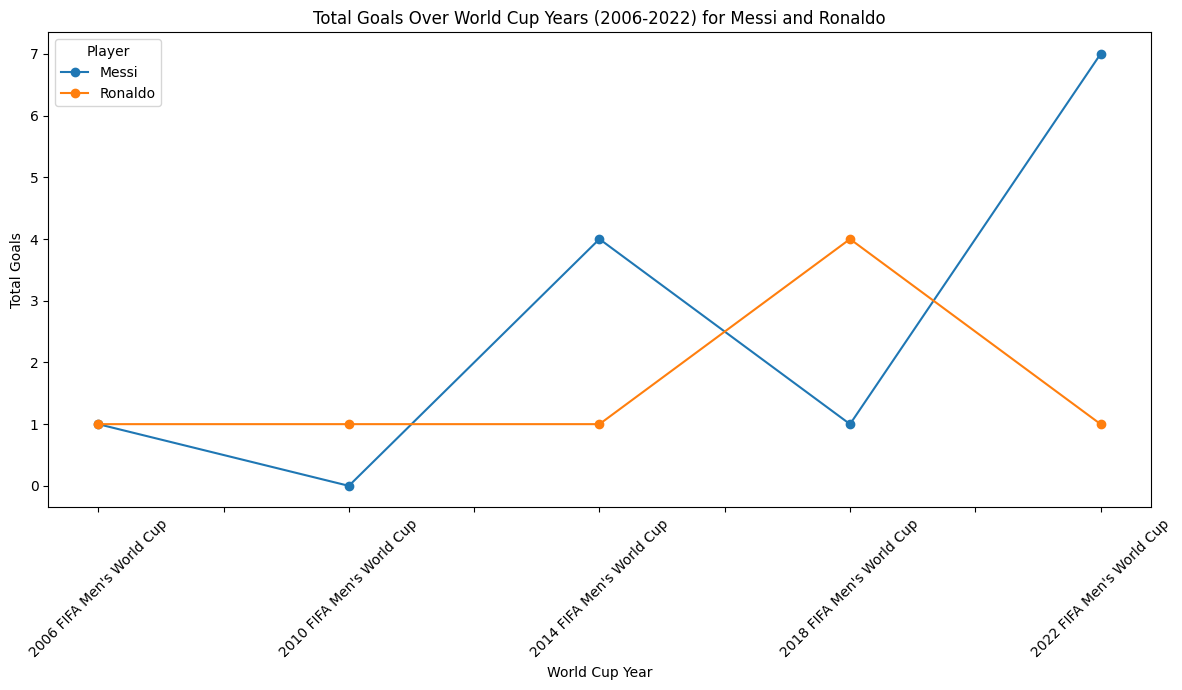

In [ ]:
# Line plot: Comparing how total goals have increased over the years for Messi and Ronaldo

athletes = WorldCup_df["family_name"].value_counts().nlargest(2).index
filtered_data = WorldCup_df[WorldCup_df["family_name"].isin(athletes)]

goalsover_WorldCup = filtered_data.groupby(['tournament_name', 'family_name'])['total_goals'].sum().unstack()

goalsover_WorldCup.plot(kind="line", marker="o", figsize=(12, 7))

plt.title("Total Goals Over World Cup Years (2006-2022) for Messi and Ronaldo")
plt.xlabel("World Cup Year")
plt.ylabel("Total Goals")
plt.xticks(rotation=45)
plt.legend(title="Player")
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()